In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, uniform, laplace, skew, kurtosis
from scipy.optimize import curve_fit

In [2]:
data=np.load('sunspot.npz')
B=data['B']
theta=np.degrees(data['inc'])
phi=np.degrees(data['az'])

#### Plotovanje mapa i histograma

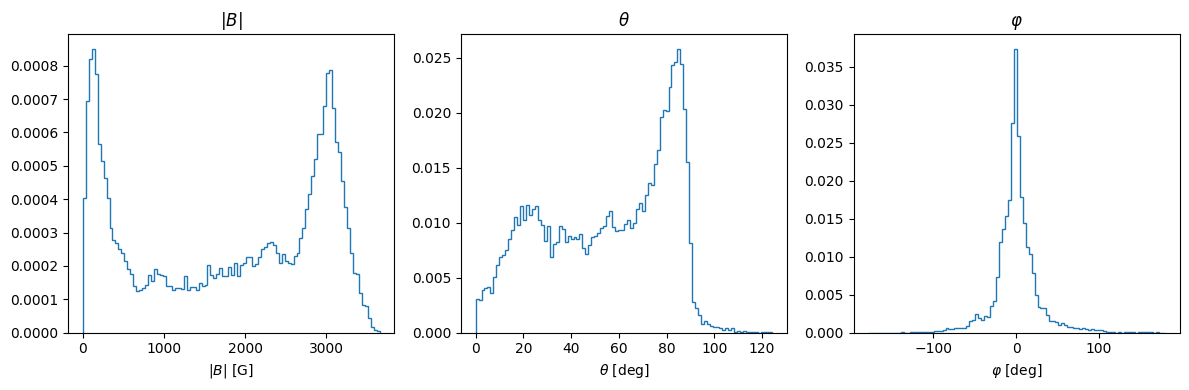

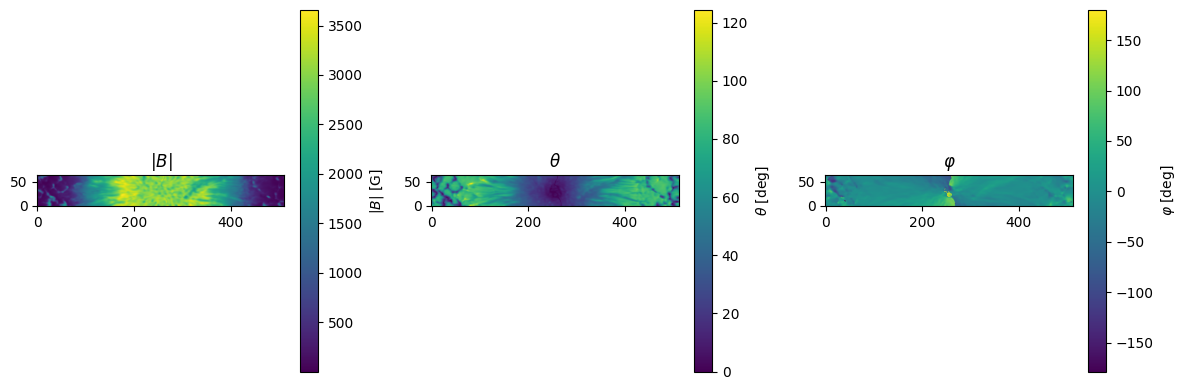

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.hist(B.ravel(), bins=100, histtype='step', density=True)
plt.xlabel(r'$|B|$ [G]')
plt.title(r'$|B|$')

plt.subplot(132)
plt.hist(theta.ravel(), bins=100, histtype='step', density=True)
plt.xlabel(r'$\theta$ [deg]')
plt.title(r'$\theta$')

plt.subplot(133)
plt.hist(phi.ravel(), bins=100, histtype='step', density=True)
plt.xlabel(r'$\varphi$ [deg]')
plt.title(r'$\varphi$')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(B, origin='lower')
plt.colorbar(label=r'$|B|$ [G]')
plt.title(r'$|B|$')

plt.subplot(132)
plt.imshow(theta, origin='lower')
plt.colorbar(label=r'$\theta$ [deg]')
plt.title(r'$\theta$')

plt.subplot(133)
plt.imshow(phi, origin='lower')
plt.colorbar(label=r'$\varphi$ [deg]')
plt.title(r'$\varphi$')

plt.tight_layout()
plt.show()

#### Modelovanje raspodela

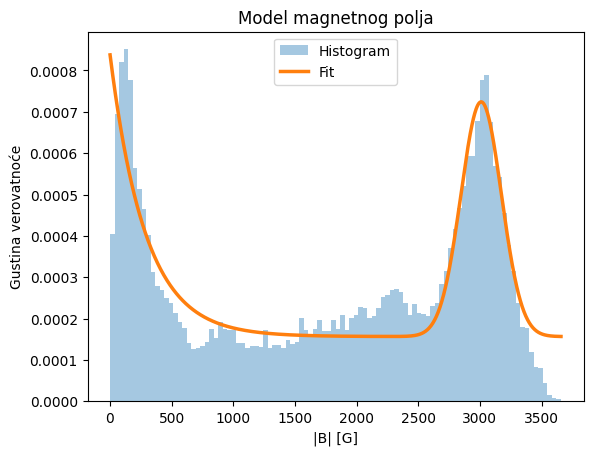

In [4]:
B = B.ravel()
B = B[np.isfinite(B)]
B_range = np.max(B) - np.min(B)
hist_B, bins_B = np.histogram(B, bins=100, density=True)
x_B = 0.5 * (bins_B[:-1] + bins_B[1:])

def B_f(x, a_norm, a_exp, a_uni, mu, sigma, tau):
    sum = a_norm + a_exp + a_uni
    w_norm = a_norm / sum
    w_exp = a_exp / sum
    w_uni = a_uni / sum
    B_f = w_norm * norm.pdf(x, loc=mu, scale=sigma) + w_exp * expon.pdf(x, loc=np.min(B), scale=tau) + w_uni * uniform.pdf(x, loc=np.min(B), scale=B_range)

    return (B_f)

p_B = [0.5,0.5,0.5, np.mean(B),np.std(B),np.std(B)]
B_par, _ = curve_fit(B_f, x_B, hist_B, p0=p_B, maxfev=20000)
x = np.linspace(np.min(B), np.max(B), 1000)

plt.hist(B, bins=100, density=True, alpha=0.4, label='Histogram')
plt.plot(x, B_f(x, *B_par), linewidth=2.5, label='Fit')
plt.xlabel('|B| [G]')
plt.ylabel('Gustina verovatnoće')
plt.title('Model magnetnog polja')
plt.legend()
plt.show()

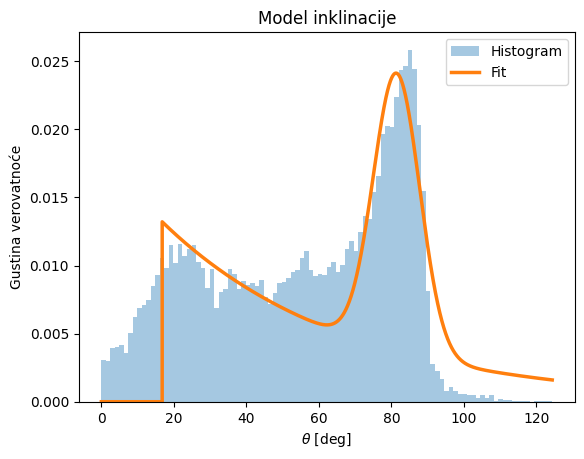

In [15]:
theta = np.degrees(data['inc'])
theta = theta.ravel()
theta = theta[np.isfinite(theta)]
theta_range = np.max(theta) - np.min(theta)
hist_theta, bins_theta = np.histogram(theta, bins=100, density=True)
x_theta = 0.5 * (bins_theta[:-1] + bins_theta[1:])

def theta_fun(x, b_norm, b_exp, mu, sigma,loc_exp,tau):
    sum = b_norm + b_exp
    w_norm = b_norm / sum
    w_exp = b_exp / sum
    theta_fun = w_norm * norm.pdf(x, loc=mu, scale=sigma) + w_exp * expon.pdf(x, loc=loc_exp, scale=tau)
    return (theta_fun)

p_theta = [0.5,0.5, np.mean(theta),np.std(theta),np.min(theta),np.std(theta)]

theta_par, _ = curve_fit(theta_fun,x_theta,hist_theta,p0=p_theta,maxfev=2000)

x = np.linspace(np.min(theta), np.max(theta), 20000)

plt.hist(theta, bins=100, density=True, alpha=0.4, label='Histogram')
plt.plot(x,theta_fun(x, *theta_par),linewidth=2.5,label='Fit')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Gustina verovatnoće')
plt.title('Model inklinacije')
plt.legend()
plt.show()

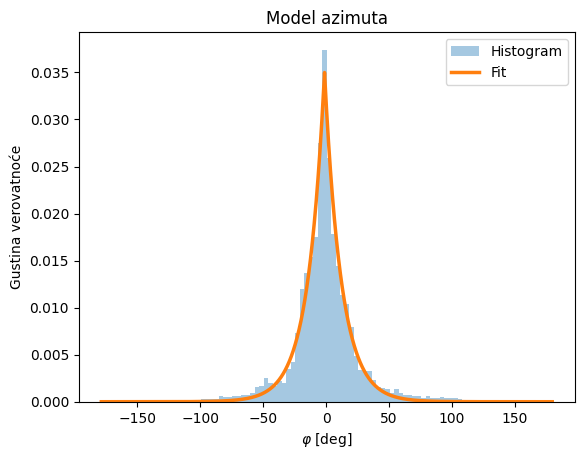

In [16]:
phi = np.degrees(data['az'])
phi = phi.ravel()
phi = phi[np.isfinite(phi)]
phi_range = np.max(phi) - np.min(phi)
hist_phi, bins_phi = np.histogram(phi, bins=100, density=True)
x_phi = 0.5 * (bins_phi[:-1] + bins_phi[1:])

def phi_fun(x, c_lap,loc_lap,tau):
    w_lap = c_lap
    phi_fun = w_lap * laplace.pdf(x, loc=loc_lap, scale=tau)
    return (phi_fun)

p_phi = [1.0, x_phi[np.argmax(hist_phi)], np.std(phi)]

phi_par, _ = curve_fit(phi_fun,x_phi,hist_phi,p0=p_phi,maxfev=2000)

x = np.linspace(np.min(phi), np.max(phi), 20000)

plt.hist(phi, bins=100, density=True, alpha=0.4, label='Histogram')
plt.plot(x,phi_fun(x, *phi_par),linewidth=2.5,label='Fit')
plt.xlabel(r'$\varphi$ [deg]')
plt.ylabel('Gustina verovatnoće')
plt.title('Model azimuta')
plt.legend()
plt.show()

#### Deskriptivne statistike

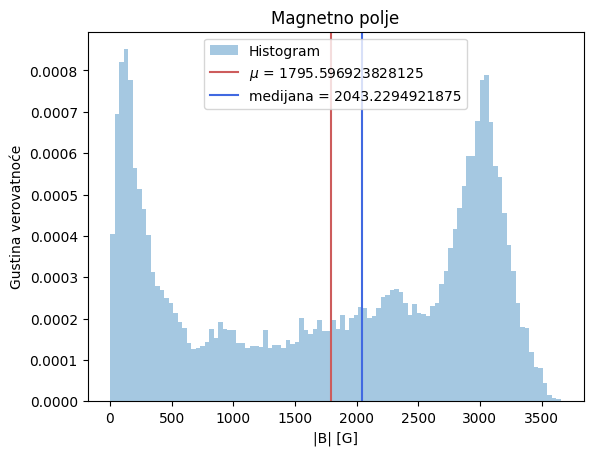

Srednja vrednost: 1795.60
Medijana: 2043.23
Standardna devijacija: 1163.67
Asimetričnost: -0.24
Kurtosis: -1.50
Devijacija: 2407.12


In [7]:
sv = np.mean(B)
med = np.median(B)
stdev = np.std(B)
s = skew(B)
k = kurtosis(B)
q25, q75 = np.percentile(B, [25, 75])
devG=q75-q25

plt.hist(B, bins=100, density=True, alpha=0.4, label='Histogram')
plt.axvline(sv, color='indianred', linestyle='-', label=r'$\mu$ = {}'.format(sv))
plt.axvline(med, color='royalblue', linestyle='-', label=r'medijana = {}'.format(med))
plt.xlabel('|B| [G]')
plt.ylabel('Gustina verovatnoće')
plt.title('Magnetno polje')
plt.legend()
plt.show()

print(f"Srednja vrednost: {sv:.2f}")
print(f"Medijana: {med:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Asimetričnost: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Devijacija: {devG:.2f}")

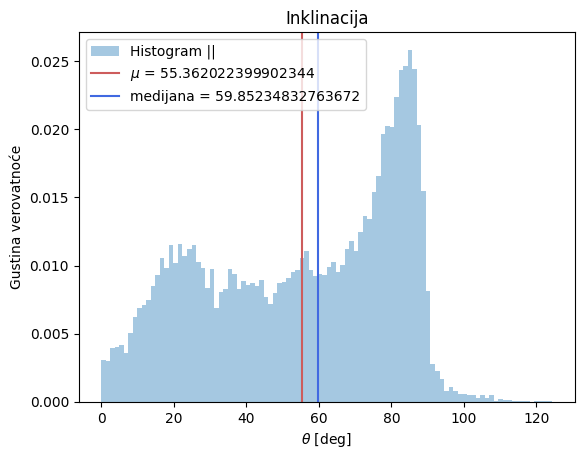

Srednja vrednost: 55.36
Medijana: 59.85
Standardna devijacija: 26.31
Asimetričnost: -0.34
Kurtosis: -1.18
Devijacija: 47.70


In [8]:
sv = np.mean(theta)
med = np.median(theta)
stdev = np.std(theta)
s = skew(theta)
k = kurtosis(theta)
q25, q75 = np.percentile(theta, [25, 75])
devG=q75-q25

plt.hist(theta, bins=100, density=True, alpha=0.4, label='Histogram ||')
plt.axvline(sv, color='indianred', linestyle='-', label=r'$\mu$ = {}'.format(sv, 2))
plt.axvline(med, color='royalblue', linestyle='-', label=r'medijana = {}'.format(med, 2))
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Gustina verovatnoće')
plt.title('Inklinacija')
plt.legend()
plt.show()

print(f"Srednja vrednost: {sv:.2f}")
print(f"Medijana: {med:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Asimetričnost: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Devijacija: {devG:.2f}")

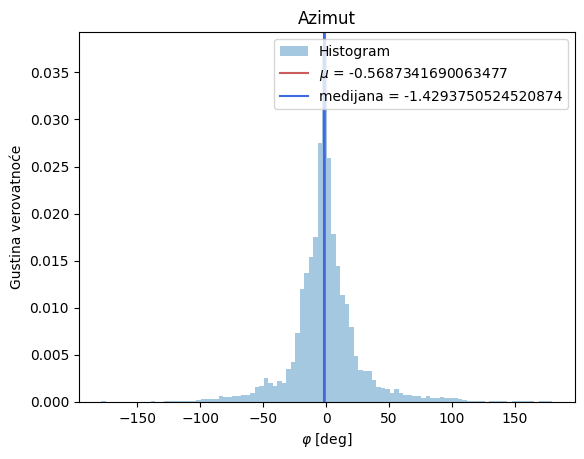

Srednja vrednost: -0.57
Medijana: -1.43
Standardna devijacija: 26.82
Asimetričnost: 0.44
Kurtosis: 5.74
Devijacija: 21.10


In [17]:
sv = np.mean(phi)
med = np.median(phi)
stdev = np.std(phi)
s = skew(phi)
k = kurtosis(phi)
q25, q75 = np.percentile(phi, [25, 75])
devG=q75-q25


plt.hist(phi, bins=100, density=True, alpha=0.4, label='Histogram')
plt.axvline(sv, color='indianred', linestyle='-', label=r'$\mu$ = {}'.format(sv, 2))
plt.axvline(med, color='royalblue', linestyle='-', label=r'medijana = {}'.format(med, 2))
plt.xlabel(r'$\varphi$ [deg]')
plt.ylabel('Gustina verovatnoće')
plt.title('Azimut')
plt.legend()
plt.show()

print(f"Srednja vrednost: {sv:.2f}")
print(f"Medijana: {med:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Asimetričnost: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Devijacija: {devG:.2f}")

Sa prva dva grafika se može primetiti loša robusnost srednje vrednosti kao deskriptivne statistike, na koju značajno utiču outlieri.

#### Provera CGT


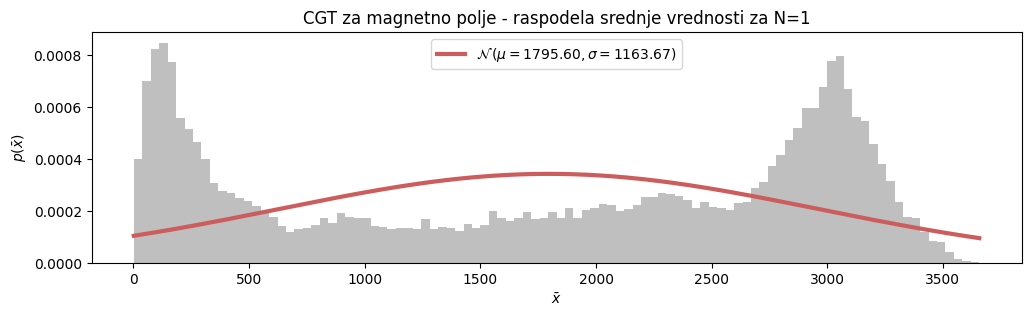

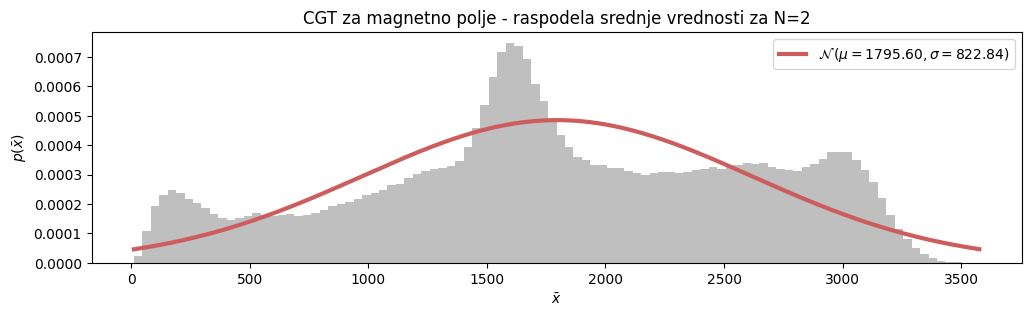

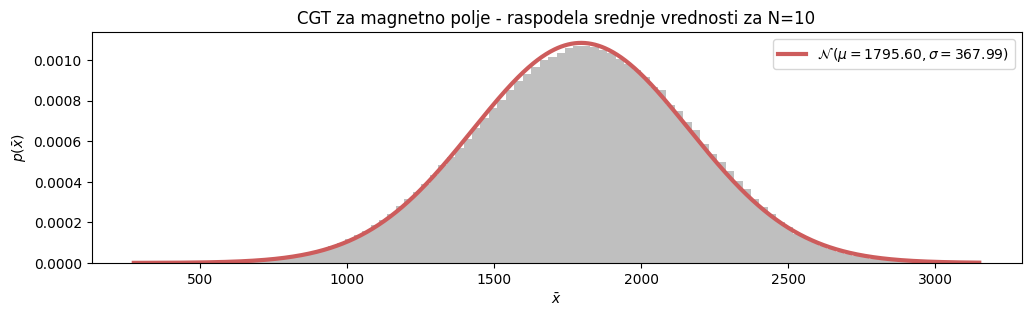

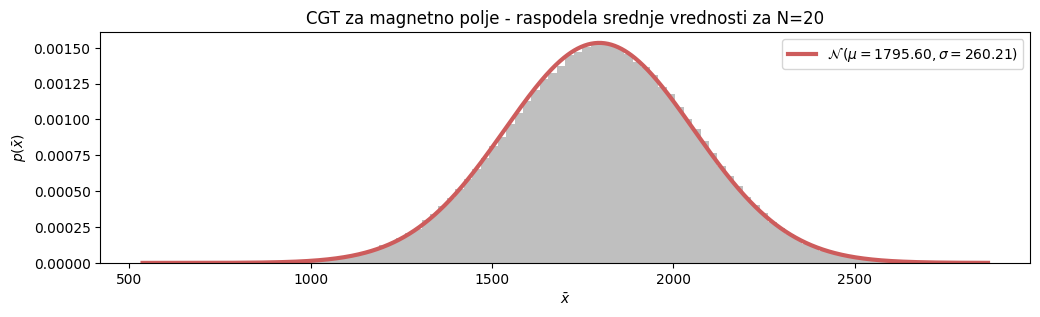

In [10]:
N = [1, 2, 10, 20]

p = B
p = p.ravel()
p = p[np.isfinite(p)]

xb = np.random.choice(p, size=(max(N), int(1e6)), replace=True)

for i in range(len(N)):
    x_i = xb[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='grey',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='indianred',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT za magnetno polje - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.show()

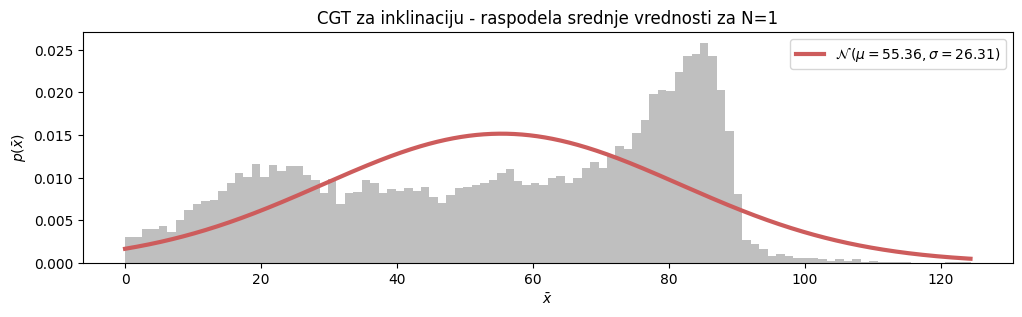

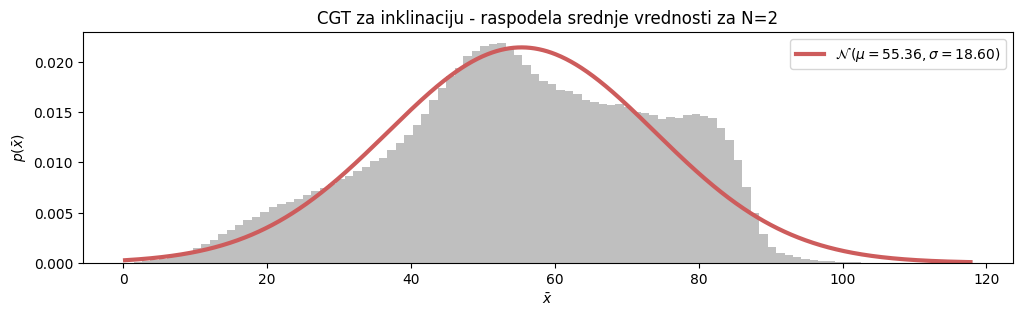

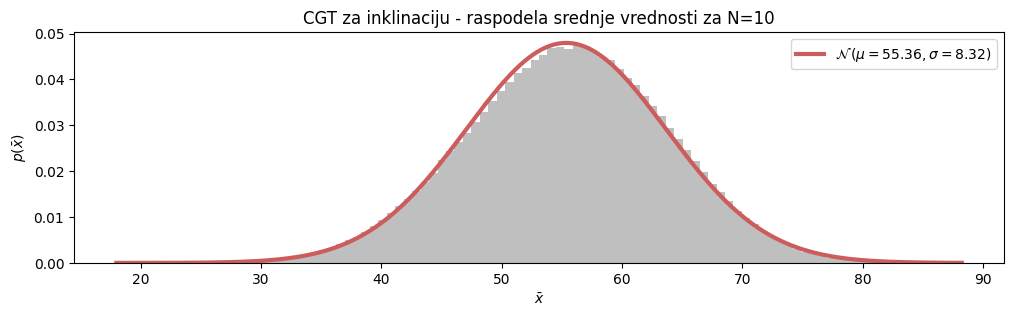

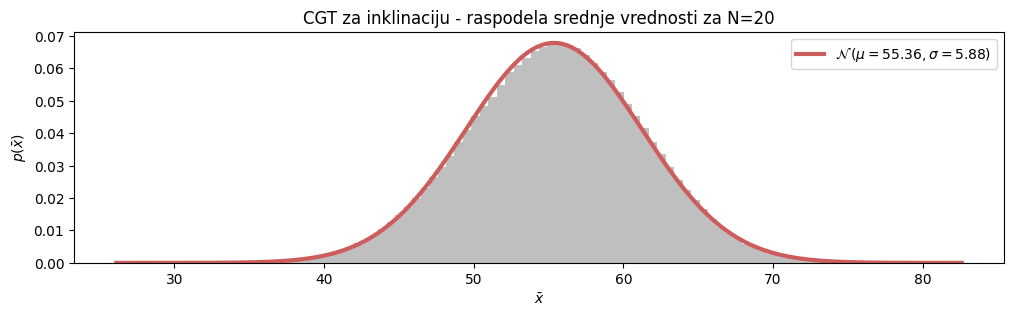

In [11]:
N = [1, 2, 10, 20]

p = theta
p = p.ravel()
p = p[np.isfinite(p)]

xb = np.random.choice(p, size=(max(N), int(1e6)), replace=True)

for i in range(len(N)):
    x_i = xb[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i, bins=100, histtype='stepfilled', density=True, color='grey', alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf, dist.pdf(x_pdf), color='indianred', lw=3,
             label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT za inklinaciju - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.show()

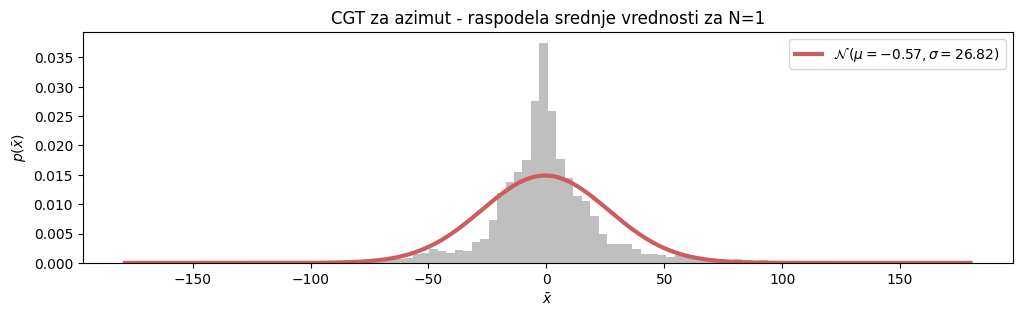

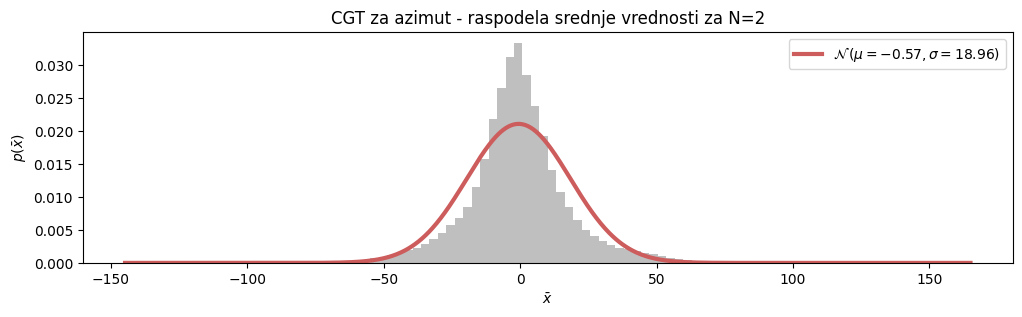

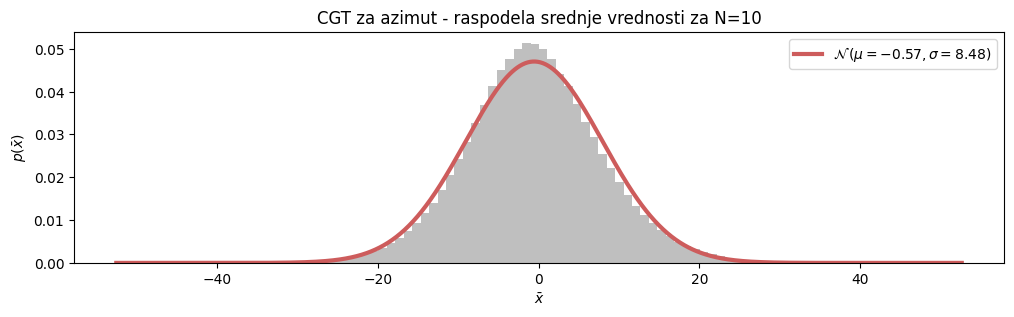

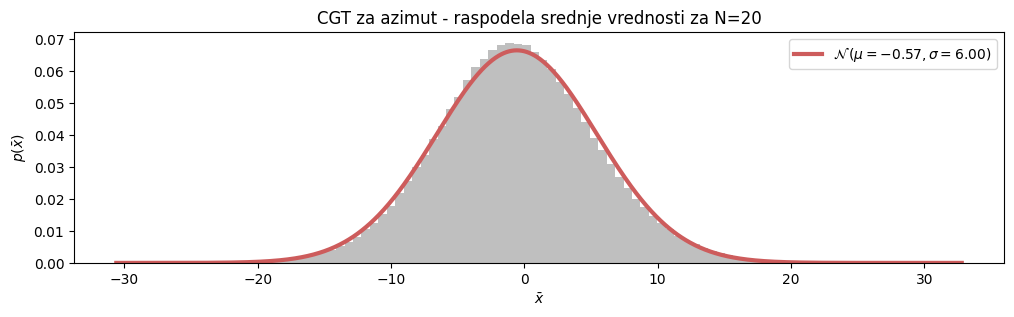

In [12]:
N = [1, 2, 10, 20]

p = phi
p = p.ravel()
p = p[np.isfinite(p)]

xb = np.random.choice(p, size=(max(N), int(1e6)), replace=True)

for i in range(len(N)):
    x_i = xb[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i, bins=100, histtype='stepfilled', density=True, color='grey', alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf, dist.pdf(x_pdf), color='indianred', lw=3,
             label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT za azimut - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.show()

Vidimo da za sve tri raspodele važi CGT.

#### Propagacija greške

In [13]:
mi0 = 4 * np.pi * 1e-7
B = B * 1e-4
P = B**2 / (2 * mi0)

s_P_d = np.std(P, ddof=1)

s_B = np.std(B,ddof=1)
dP_dB = np.mean(B) / mi0
s_P_p = s_B * abs(dP_dB)


ods_aps = abs(s_P_p - s_P_d)
ods_rel = ods_aps / s_P_d

print("Vrednost dobijena direktno iz P:", s_P_d)
print("Vrednost dobijena propagacijom:", s_P_p)
print("Apsolutno odstupanje", ods_aps)
print("Relativno odstupanje =", ods_rel)

Vrednost dobijena direktno iz P: 15740.621
Vrednost dobijena propagacijom: 16627.889
Apsolutno odstupanje 887.2676
Relativno odstupanje = 0.056368016
